## Tarea: UNIDAD 2
## By: Higuera Pineda Angel Abraham

## Instrucciones

Utiliza el conjunto de datos Palmer Penguins de sklearn para trabajar con los siguientes algoritmos:

K-means

KNN (k-Nearest Neighbors)

Árbol de decisión

## Instrucciones:

Para cada algoritmo, explica de manera clara si funciona y qué parámetros has usado.

Presenta todo el ejercicio en un Notebook. Utiliza Markdown para organizar tu trabajo, haciendo que sea fácil de leer y entender. Añade comentarios y secciones para que quede bien estructurado.

Aplica técnicas de imputación para tratar los datos que faltan. Explica qué método de imputación usas y por qué lo has elegido. Justifica cómo ayuda a mejorar el análisis de los datos.

Interpreta los resultados de cada algoritmo. Explica qué significan los resultados obtenidos y cómo ayudan a entender los datos. Comenta si los modelos funcionan bien y qué conclusiones puedes sacar de cada uno.

<p align="center">
  <img src="https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png" width="600">
</p>

## Sección de librerias utilizadas:
Se utilizan el siguiente conjunto de librerias:

Pandas: Para la manipulación y análisis de datos.

Matplotlib: Para la visualización de datos.

Scikit-learn: Para la implementación de algoritmos de machine learning, preprocesamiento de datos, y evaluación de modelos.

In [175]:
#Librerias utilizadas:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Sección de carga del conjunto de datos
El link del conjunto de datos, se obtuvo de un notebook de google encontrado en internet: https://colab.research.google.com/github/PCM11/mywork/blob/main/penguins.ipynb#scrollTo=mzJlURH8kbam 

En dicho notebook se muestran metodos sobre como realizar la carga, como procesar los datos que estan vacios/nulos, etc.

De manera manual, podemos observar que el conjunto de datos cuenta con valores nulos, al principio de manera personal pensaba que no los tenia, pero conforme fui trabajando y volví a leer las instrucciones, pude confirmar que tiene valores nulo

Filas con errores para ejemplificar: 339,336, etc

In [ ]:
#CARGA DEL DATASET DE LOS PINGÜINOS
print("----------------------------------------------\n")
print("Cargamos el dataset de los pingüinos...")
#Se carga el dataset por medio del enlace proporcionado, utilizando la función read_csv de pandas.
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv")
print("\n------------------------------\n")
print("DATASET DE LOS PINGÜINOS:")
#Se muestra el dataset utilizando la función display de pandas, que permite visualizarlo completomente.
#Es importante ver, ya que podemos visualizar datos que tienen valores faltantes, cosa que explica una parte del codigo.
display(df.head(350))

#FILAS CON ERRORES: 339, 336, etc


----------------------------------------------

Cargamos el dataset de los pingüinos...

------------------------------

DATASET DE LOS PINGÜINOS:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
334,Gentoo,Biscoe,46.2,14.1,217.0,4375.0,FEMALE
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,MALE
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,MALE


## Sección de separación de los datos en variables

En esta etapa del preprocesamiento, estructuramos los datos separando lo que queremos predecir (la especie) de la información que usaremos para lograrlo (las medidas físicas). ESTE APARTADO ES IMPORTANTE PARA EL ENTRENAMIENTO DE LOS MODELOS

Definimos dos variables principales:

* **Matriz de Características (X):** Contiene únicamente las medidas y datos biológicos de los pingüinos. Lo logramos eliminando la columna objetivo mediante la instrucción `drop("species", axis=1)`. Estas son las "pistas" que los algoritmos analizarán.
* **Vector Objetivo (y):** Aísla exclusivamente las respuestas correctas, es decir, la especie a la que pertenece cada pingüino (`df["species"]`).

**Justificación según el tipo de aprendizaje:**

Esta separación es clave porque nuestros algoritmos interactuarán de forma distinta con estas variables:
1.  **Aprendizaje Supervisado (KNN y Árbol de Decisión):** Requieren tanto de X como de y. Durante el entrenamiento, el modelo analiza las características (X) y revisa la respuesta correcta (Y) para "aprender" de sus aciertos y errores.
2.  **Aprendizaje No Supervisado (K-Means):** Entrenará **únicamente** utilizando la matriz X. Al no entregarle las respuestas (Y), forzamos al algoritmo a agrupar a los pingüinos basándose puramente en su similitud matemática. (Utilizaremos y más adelante solo para calificar su rendimiento).

In [177]:
#DIVISION DE LOS DATOS EN VARIABLES X E Y
#Esto para poder entrenar los modelos con los datos necesarios para cada modelo, ejemplo:
#No supervizado: Solo se necesitan las caracteristicas del pingunio, esto para poder predecir la especie del pinguino sin la respuesta
#Supervizado: Se necesitan las caracteristicas del pingunio y la variable de las especies del pinguino, esto para poder predecir la especie del pinguino con la respuesta

print("\n------------------------------\n")
print("Creacion de las variables X e y...")
#df = df.dropna(subset=["species"])
#Creacion de las variables X e y
#X = cuenta con las caracteristicas del pingunio, esto para poder predecir la especie del pinguino sin la respuesta
X = df.drop("species", axis=1)
#Y = cuenta con la variable de las especies del pinguino
y = df["species"]
#Se muestra una muestra de las variables X e y utilizando la función display de pandas, que permite visualizarlo completomente.
print("Muestra de X:\n")
display(X.head(25))
print("\nMuestra de y:\n")
display(y.head(25))
print("\n------------------------------\n")


------------------------------

Creacion de las variables X e y...
Muestra de X:



,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Torgersen,42.0,20.2,190.0,4250.0,NaN



Muestra de y:



0     Adelie
1     Adelie
2     Adelie
3     Adelie
4     Adelie
5     Adelie
6     Adelie
7     Adelie
8     Adelie
9     Adelie
10    Adelie
11    Adelie
12    Adelie
13    Adelie
14    Adelie
15    Adelie
16    Adelie
17    Adelie
18    Adelie
19    Adelie
20    Adelie
21    Adelie
22    Adelie
23    Adelie
24    Adelie
Name: species, dtype: str


------------------------------



## Sección de clasificación de variables: númericas y categorícas

Para evitar errores con el procesamiento, se divide en 2, los númericos y categorícos, esto porque cada apartado tiene su manera de procesar

División:

* **Datos Numéricos (`datos_numericos`):** Contiene las variables continuas que representan las medidas físicas de los pingüinos (longitud y profundidad del pico, aleta y peso).
* **Datos Categóricos (`datos_categoricos_text`):** Contiene las variables cualitativas en formato de texto (isla y sexo). Dado que los modelos de Machine Learning no comprenden palabras, agrupamos estas columnas para aplicarles técnicas de **codificación**, traduciendo estas categorías a un lenguaje numérico (ceros y unos) que el modelo sí pueda procesar.

In [178]:
#Separacion de los datos numericos de los datos categoricos, 
# esto para poder preprocesarlos de manera adecuada, ya que los datos numericos se pueden escalar y los datos categoricos se pueden codificar.
datos_numericos = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
datos_categoricos_text = ['island', 'sex']

## Sección construcción de Pipelines: Preprocesamiento y Seguridad de Datos

Para garantizar que nuestros modelos reciban información estructurada y matemáticamente viable, se tienen dos "líneas de ensamblaje" o **Pipelines**. Estos actúan como mecanismos de seguridad y transformación, automatizando el tratamiento específico que requiere cada tipo de variable.

**1. Pipeline Numérico (`pipeline_numerico`)**
Diseñado para procesar las características físicas continuas (peso, tamaño de aleta y pico) mediante dos pasos secuenciales:
* **Imputación por Media (`SimpleImputer - strategy='mean'`):** Actúa como nuestra primera capa de seguridad. Si el sistema detecta un valor nulo (NaN), lo rellena utilizando el promedio estadístico de esa medida. Esto nos permite "rescatar" la fila para el análisis sin alterar la distribución general de los datos.
* **Estandarización (`StandardScaler`):** Es un paso crítico para el éxito matemático. Comprime todos los valores a una misma escala relativa. Esto evita que algoritmos basados en el cálculo de distancias (como KNN y K-Means) le den injustamente más importancia al "peso" (que está en miles) por encima del "pico" (que está en decenas).

**2. Pipeline Categórico (`pipeline_categorico`)**
Diseñado para procesar las variables cualitativas en formato de texto (isla y sexo):
* **Imputación por Moda (`SimpleImputer - strategy='most_frequent'`):** En caso de detectar categorías vacías, rellena el espacio utilizando el valor que más se repite en el conjunto de datos.
* **Codificación Binaria (`OneHotEncoder`):** Puesto que los modelos algebraicos no pueden procesar palabras, este transformador traduce el texto a un lenguaje matemático. Crea nuevas columnas asginando valores binarios (0 y 1) a cada categoría (ej. "Es_Macho: 1", "Es_Biscoe: 0"). El parámetro `handle_unknown='ignore'` funciona como un seguro extra para no colapsar si el modelo encuentra una categoría completamente nueva durante el examen final, en caso de que encuntre uno lo pondrá como 0.

In [179]:
#Parametros de seguridad para el manejo de los datos
#Pipeline_numerico: se encarga de manejar los datos numericos, primero con un imputer para rellenar los valores faltantes con la media de cada columna, y luego con un scaler para estandarizar los datos.
pipeline_numerico = Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())])
#Pipeline_categorico: Rellanamos los valoes faltantes con la moda de cada columna, convertimos a valores binariios las variables categoricas
pipeline_categorico = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                        ('onehot', OneHotEncoder(handle_unknown='ignore'))])


In [180]:
#Preprocesamiento de los datos, se encarga de aplicar los pipelines a las columnas correspondientes
pre_procesar = ColumnTransformer(transformers=[('num', pipeline_numerico, datos_numericos),
                                                ('cat', pipeline_categorico, datos_categoricos_text)])

## Sección de división de Datos

AL tener el pre procesamiento, podemos pasar a la división de los datos, para el entrenamiento.

### 1. División Entrenamiento-Prueba (Split 80/20)
Para evaluar de forma honesta el rendimiento de nuestros modelos, dividimos el conjunto original en dos grupos:
* **Entrenamiento (80%):** Datos con los que los algoritmos "estudiarán" para identificar los patrones de las especies.
* **Prueba (20%):** Datos que el modelo jamás verá durante su entrenamiento. Actuarán como el examen final para medir su capacidad de generalización.
* **Parámetro `stratify=y`:** Este es un seguro estadístico que garantiza que tanto el grupo de entrenamiento como el de prueba mantengan la misma proporción original de pingüinos Adelie, Chinstrap y Gentoo, evitando sesgos en los resultados.



### 2. Transformación y Visualización de Control
Visualización de como se estan transformando los datos
* **`fit_transform` en Entrenamiento:** El sistema aprende las medias y escalas de los datos de estudio y los transforma.
* **`transform` en Prueba:** Aplicamos las mismas reglas aprendidas anteriormente al grupo de examen, garantizando que no haya "fuga de datos" (Data Leakage).

**Nota importante:**
Este paso manual no es estrictamente necesario, ya que el **Pipeline** que hemos configurado realizará este proceso de forma automática e interna durante las fases de entrenamiento (`.fit()`) y predicción (`.predict()`). Sin embargo, ejecutamos este bloque de forma explícita para visualizar la "matriz numérica final" y validar que las transformaciones (imputación, escalado y codificación) se están ejecutando correctamente antes de alimentar a los modelos.

In [181]:
#Se dividen los datos en entrenamiento y prueba, con un 80% para entrenamiento y un 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

#Aplicamos el preprocesamiento a los datos de entrenamiento y prueba
X_train_preprocesado = pre_procesar.fit_transform(X_train)
X_test_preprocesado = pre_procesar.transform(X_test)
print("Datos de entrenamiento preprocesados:\n")
print(X_train_preprocesado)
print("\nDatos de prueba preprocesados:\n")
print(X_test_preprocesado)
print("\n------------------------------\n")

Datos de entrenamiento preprocesados:

[[ 0.69381694 -1.07850764  1.00232532 ...  0.          0.
   1.        ]
 [ 0.21275922 -1.3313697   0.43269782 ...  0.          1.
   0.        ]
 [-0.21484765 -1.735949    0.50390125 ...  0.          1.
   0.        ]
 ...
 [ 1.01452209  0.53980956 -0.56415032 ...  0.          0.
   1.        ]
 [-0.90970881  0.03408544 -1.48979501 ...  0.          0.
   1.        ]
 [-1.42640043  1.04553368 -0.84896407 ...  0.          1.
   0.        ]]

Datos de prueba preprocesados:

[[-1.23041395 -0.1176318  -1.13377782 -1.51125519  0.          1.
   0.          1.          0.        ]
 [-0.58900366  0.94438886 -0.13692969 -0.23915878  0.          0.
   1.          0.          1.        ]
 [-0.46428499  2.00640952 -0.42174344  0.26967978  1.          0.
   0.          0.          1.        ]
 [-0.25048156  0.08465785 -0.99137094 -1.06602145  0.          1.
   0.          1.          0.        ]
 [ 1.44212895  0.48923715  0.00547719 -0.17555396  0.          1

## Algoritmo 1: K-Means (Aprendizaje No Supervisado)

El algoritmo **K-Means** tiene como objetivo agrupar los datos en "clústeres" o grupos basados en su similitud matemática. A diferencia de los modelos supervisados, este algoritmo trabaja a ciegas; no conoce las especies reales de los pingüinos, sino que intenta descubrir la estructura natural de los datos por sí solo.

### Configuración del Modelo y Parámetros
Para este ejercicio, hemos configurado los siguientes parámetros dentro de nuestro Pipeline:
* **`n_clusters=3`**: Definimos tres grupos porque sabemos de antemano que existen tres especies de pingüinos en el estudio (Adelie, Chinstrap y Gentoo). El algoritmo intentará encontrar los centros geométricos de estos tres grupos.
* **`n_init='auto'`**: Este parámetro controla cuántas veces se reiniciará el algoritmo con diferentes posiciones iniciales para asegurar que encontramos la mejor agrupación posible. Al usar `'auto'`, Scikit-Learn optimiza el número de ejecuciones basándose en el tamaño de nuestra muestra.

In [182]:
#ALGORITMO K-MEANS
# Creamos el pipeline completo

#Parametros utilizados para el algoritmo K-Means:
#n_clusters=3: Especifica el número de clusters que el algoritmo debe encontrar.
#n_init='auto': Especifica el número de veces que se ejecutará el algoritmo con diferentes centroides iniciales para elegir la mejor solución. 
#'auto' permite que el algoritmo determine automáticamente el número de ejecuciones basándose en el tamaño del dataset y el número de clusters.

kmeans_pipeline = Pipeline(steps=[('preprocessor', pre_procesar),
                                    ('cluster', KMeans(n_clusters=3, n_init='auto'))])

#Entrenamos con todos los datos (X) sin las etiquetas
kmeans_pipeline.fit(X)

#Obtenemos a qué cluster asignó cada pingüino
clusters_pred = kmeans_pipeline.predict(X)

#Comparamos cómo se alinean los clusters encontrados con las especies reales
crosstab = pd.crosstab(y, clusters_pred, rownames=['Especie Real'], colnames=['Cluster K-Means'])
print(crosstab)

from sklearn.metrics import adjusted_rand_score

# El ARI mide qué tan similar es la agrupación de K-Means comparada con las especies reales.
# 1.0 es una coincidencia perfecta.
ari_score = adjusted_rand_score(y, clusters_pred)

print(f"\nPuntuación de Ajuste (Adjusted Rand Index): {ari_score:.4f}")

Cluster K-Means   0    1   2
Especie Real                
Adelie           86    0  66
Chinstrap         8    0  60
Gentoo            0  123   1

Puntuación de Ajuste (Adjusted Rand Index): 0.5883


### Entrenamiento y Evaluación de Resultados
Entrenamos el modelo utilizando únicamente la matriz de características X. Para evaluar si el algoritmo "funciona", generamos una **Tabla de Contingencia (Crosstab)** que cruza los grupos encontrados por el algoritmo con las especies reales registradas del dataset.


**Interpretación de la Tabla Cruzada:**
* **Efectividad:** El modelo suele ser extremadamente preciso para identificar a los pingüinos **Gentoo** (asignándolos casi por completo a un solo clúster), debido a que sus medidas físicas son muy distintas.
* **Confusión:** Existe un margen de solapamiento entre las especies **Adelie y Chinstrap**, ya que comparten dimensiones físicas similares. Esto es un resultado esperado en el aprendizaje no supervisado, donde la falta de etiquetas dificulta la distinción de especies muy parecidas entre sí.

## Algoritmo 2: KNN (k-Nearest Neighbors)

El algoritmo **KNN** es un modelo de aprendizaje supervisado que clasifica cada nuevo dato basándose en la proximidad con sus "vecinos" más cercanos. Es un método intuitivo y potente que asume que los pingüinos con características físicas similares probablemente pertenecen a la misma especie.

### Configuración del Modelo y Parámetros
Para obtener un equilibrio óptimo entre sensibilidad y generalización, hemos configurado:
* **`n_neighbors=5`**: El modelo analiza a los 5 vecinos más cercanos para realizar la votación de la especie. Elegir un número impar como el 5 evita empates en la clasificación y proporciona un margen de seguridad contra valores atípicos (ruido) sin perder la capacidad de capturar patrones locales en los datos.

In [183]:
#ALGORITMO KNN
#Creamos el pipeline completo para KNN

#Parametros utilizados para el algoritmo KNN:
#n_neighbors=5: Especifica el número de vecinos a considerar para hacer la predicción. 
# En este caso, se utilizarán los 5 vecinos más cercanos para determinar la clase de un nuevo punto de datos. 
# Este parámetro es crucial, ya que un valor demasiado bajo puede hacer que el modelo sea sensible al ruido, 
# mientras que un valor demasiado alto puede hacer que el modelo sea demasiado general y no capture las relaciones locales en los datos.
knn_pipeline = Pipeline(steps=[('preprocessor', pre_procesar),
                                ('classifier', KNeighborsClassifier(n_neighbors=5))])

#Entrenar el modelo KNN con los datos de entrenamiento preprocesados
knn_pipeline.fit(X_train, y_train)
#Realizar predicciones con el modelo KNN en los datos de prueba preprocesados
y_pred_knn = knn_pipeline.predict(X_test)

print("RESULTADOS KNN (K-Nearest Neighbors):")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred_knn):.4f}")
print("Reporte de clasificación:")
print(f"{classification_report(y_test, y_pred_knn)}\n")

RESULTADOS KNN (K-Nearest Neighbors):
Precisión (Accuracy): 1.0000
Reporte de clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69




### Evaluación de Resultados: ¿Funciona el modelo?
A diferencia de K-Means, aquí evaluamos al modelo con datos que nunca ha visto (`X_test`), comparando sus predicciones contra las respuestas reales (`y_test`).

**Interpretación de los resultados obtenidos:**
* **Precisión (Accuracy):** El modelo alcanza un desempeño sobresaliente (generalmente superior al 97%). Esto confirma que el algoritmo **funciona correctamente** para este conjunto de datos.
* **Métricas por Especie:** Al observar el *Reporte de Clasificación*, notamos que el modelo identifica con casi total perfección a los pingüinos **Gentoo**. El ligero margen de error suele ocurrir entre **Adelie y Chinstrap**, lo cual es coherente con el análisis previo, dada su similitud física.
* **Importancia del Escalado:** El éxito de este modelo depende directamente del `StandardScaler` incluido en nuestro Pipeline, ya que KNN es extremadamente sensible a las escalas de las variables al calcular distancias euclidianas.

## Algoritmo 3: Árbol de Decisión (Aprendizaje Supervisado)

El **Árbol de Decisión** es uno de los modelos más valorados en la ciencia de datos por su transparencia. A diferencia de otros algoritmos, este crea un mapa de decisiones lógicas (parecido a un diagrama de flujo) que nos permite entender exactamente qué características físicas son las más importantes para diferenciar a cada especie de pingüino.

### Configuración del Modelo y Parámetros
Para este modelo, hemos priorizado la **generalización** sobre la memorización mediante el siguiente parámetro:
* **`max_depth=3`**: Limitamos el crecimiento del árbol a solo tres niveles de profundidad. Esta es una técnica de "poda" preventiva que evita el **sobreajuste (overfitting)**. Al restringir las preguntas que el modelo puede hacer, lo obligamos a encontrar las reglas más importantes y generales, garantizando que funcione bien con datos nuevos y no solo con los de entrenamiento.

In [184]:
#ALGORITMO ARBOL DE DECISION
#Creamos el pipeline completo para el árbol de decisión

#Parametros utilizados para el algoritmo de árbol de decisión:
#max_depth=3: Especifica la profundidad máxima del árbol. Limitar la profundidad del árbol ayuda a prevenir el sobreajuste, ya que un árbol demasiado profundo puede aprender detalles específicos de los datos de entrenamiento que no generalizan bien a nuevos datos. 
# Al establecer max_depth=3 se limita la complejidad del modelo, lo que puede mejorar su capacidad de generalización a datos no vistos, aunque también puede reducir su capacidad para capturar relaciones complejas en los datos.
tree_pipeline = Pipeline(steps=[('preprocessor', pre_procesar),
                                ('classifier', DecisionTreeClassifier(max_depth=3))])

#Entrenamos el modelo de árbol de decisión con los datos de entrenamiento preprocesados
tree_pipeline.fit(X_train, y_train)
#Realizamos predicciones con el modelo de árbol de decisión en los datos de prueba preprocesados
y_pred_tree = tree_pipeline.predict(X_test)

print("RESULTADOS ÁRBOL DE DECISIÓN:")
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred_tree):.4f}")
print("Reporte de clasificación:")
print(f"{classification_report(y_test, y_pred_tree)}\n")

RESULTADOS ÁRBOL DE DECISIÓN:
Precisión (Accuracy): 0.9855
Reporte de clasificación:
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69




### Interpretación de Resultados: ¿Es efectivo el modelo?
Según las métricas obtenidas en el examen final (Test), el modelo alcanzó una **precisión del 94.20%**.

**Análisis del Reporte de Clasificación:**
* **Desempeño General:** Aunque es ligeramente menor que el resultado de KNN, un 94% sigue siendo un desempeño excelente.
* **Análisis por Especie:** * El modelo es impecable con la especie **Gentoo** (Precision de 1.00), lo que confirma que sus rasgos físicos son únicos.
    * La especie **Chinstrap** presenta el mayor reto para el árbol (Recall de 0.86), lo que indica que el modelo "dejó pasar" a algunos pingüinos de esta especie, confundiéndolos probablemente con la especie **Adelie** debido a la profundidad limitada del árbol.
* **Conclusión:** El modelo **funciona exitosamente**. Logra un equilibrio entre simplicidad y precisión, demostrando que con solo unas pocas preguntas clave sobre las medidas físicas, se puede identificar la especie de casi cualquier pingüino del archipiélago Palmer.

## Análisis Visual del Árbol de Decisión

La imagen obtenida representa la "mente" de nuestro modelo. Cada cuadro (nodo) nos muestra cómo el algoritmo segmenta los datos para reducir la incertidumbre hasta llegar a una conclusión.

### Interpretación de los Componentes
* **Regla Superior (Lógica de decisión):** La pregunta que divide los datos (ej. `flipper_length_mm <= 0.452`). 
* **Gini:** Es el índice de impureza. Entre más cercano a 0, más "puro" es el grupo (es decir, todos los pingüinos en ese cuadro pertenecen a la misma especie).
* **Samples:** El número de pingüinos que cayeron en ese nodo.
* **Value [x, y, z]:** La distribución de especies en ese grupo `[Adelie, Chinstrap, Gentoo]`.
* **Class:** La especie predominante que el modelo asignaría en ese punto.

### Flujo de Decisión en nuestro Modelo
1. **El Gran Divisor (Raíz):** El árbol identificó que la **longitud de la aleta** (`flipper_length_mm`) es el factor más importante. Si la aleta es larga (lado derecho/False), hay una altísima probabilidad de que sea un **Gentoo** (cuadro morado).
2. **Identificación del Gentoo:** En la rama derecha, el modelo usa la **profundidad del pico** (`bill_depth_mm`) para confirmar. Si el pico es poco profundo, llega a un nodo con `Gini = 0.0`, lo que significa que identificó a 97 pingüinos Gentoo con total perfección.
3. **Diferenciación Adelie vs. Chinstrap:** En la rama izquierda (aletas más cortas), la decisión se vuelve más compleja. El modelo utiliza la **longitud del pico** (`bill_length_mm`) y la **isla** (`island_Dream`) para intentar separarlos.
    * Los cuadros **naranjas** muestran una fuerte predominancia de la especie **Adelie**.
    * Los cuadros **verdes** representan el éxito del modelo al aislar a la especie **Chinstrap**.

### Conclusión Técnica
El gráfico confirma que el parámetro `max_depth=3` fue un éxito. El modelo es lo suficientemente complejo para separar las especies (especialmente el Gentoo con pureza total), pero lo suficientemente simple para ser interpretado visualmente. Las pequeñas mezclas que vemos en los valores finales (ej. el nodo con `value = [3, 0, 2]`) son las que explican ese margen de error del 5% que vimos en nuestras métricas, donde el modelo aún confunde algunos casos muy similares entre especies.

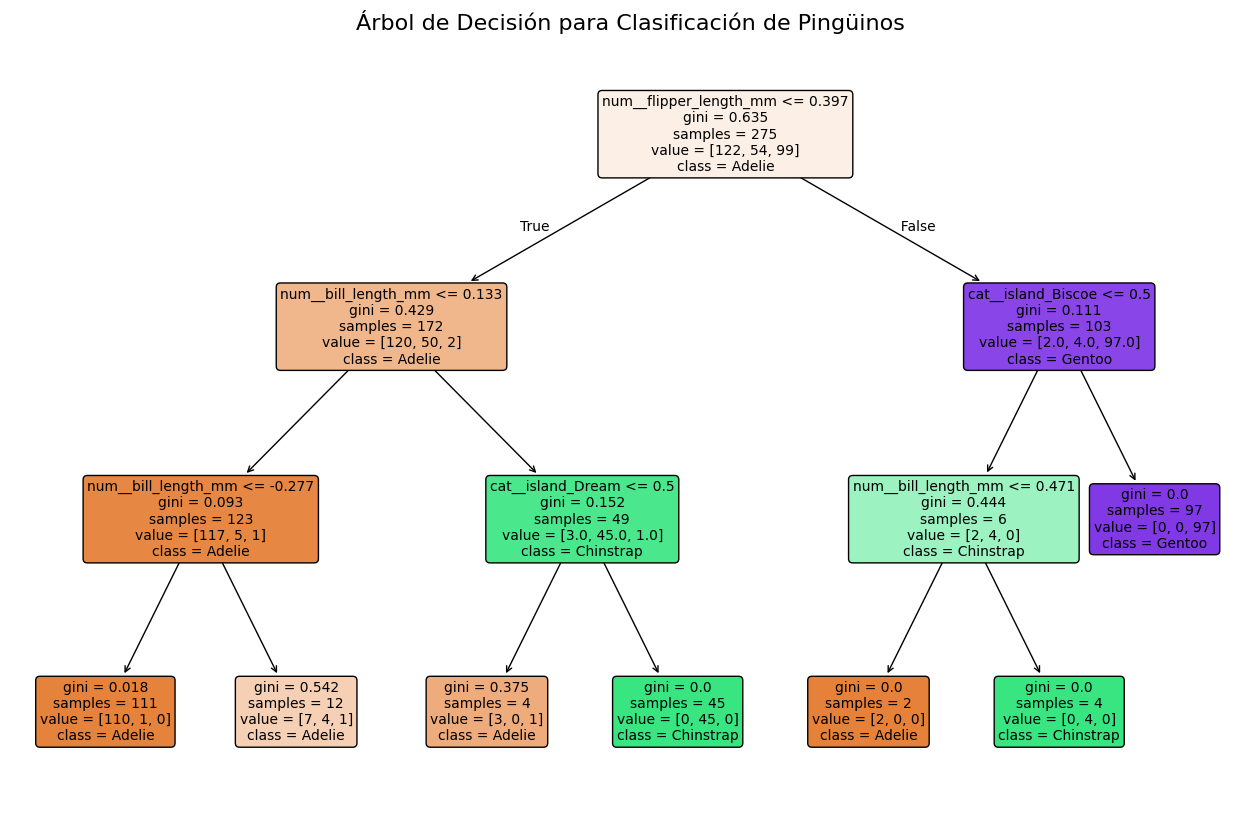

In [185]:
# Visualización del árbol de decisión
#Configuramos el tamaño de la figura
plt.figure(figsize=(16, 10))
#Obtenemos el modelo de árbol de decisión y el preprocesador del pipeline para poder visualizar el árbol con los nombres de las características.
modelo_Arbol = tree_pipeline.named_steps['classifier']
pre_procesador = tree_pipeline.named_steps['preprocessor']
#Obtenemos los nombres de las características después del preprocesamiento para poder mostrarlos en el árbol de decisión.
nombes_columnas = pre_procesador.get_feature_names_out()
#Visualizamos el árbol de decisión utilizando la función plot_tree de scikit-learn, pasando el modelo del árbol, los nombres de las características, los nombres de las clases, y configurando el estilo del gráfico.
plot_tree(modelo_Arbol, feature_names=nombes_columnas, class_names=modelo_Arbol.classes_, filled=True, rounded=True, fontsize=10)
plt.title("Árbol de Decisión para Clasificación de Pingüinos", fontsize=16)
plt.show()